# Visualize reults from tuners forE coli MG1655 DAEs

### Georgia Doing 2025

Tuners were run by run_tuner_07_21_2025.py


In [1]:
import run_model_preT
import run_model
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#from imp import reload
import Adage
from scipy.stats import hypergeom
import csv
from AdageHyperModelv2 import AdageHyperModelv2
import tensorflow as tf
import shap
from keras.models import Model, load_model
import keras_tuner as kt
import random

import os
import re
import sys

True


In [46]:
tf.__version__
tf.compat.v1.enable_eager_execution()
print(sys.version)

3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:21:13) [GCC 13.3.0]


In [47]:

print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  0
True


In [48]:
# for dev purposes, while updating run_model.py need to reload
# for dev purposes, while updating run_model.py need to reload
#reload(run_model_preT)
#reload(run_model)
#reload(Adage)

## Base features (from ADAGE)

For the sake of this efficiency, starting with the following parameters:

* hidden features: 300
* epochs: 500
* curruption: 0.01
* batchs zie: 10
* validatoin split: 0.1
* activation: sigmoid
* objective: binary cross-entropy



In [30]:
all_comp = np.loadtxt(open('../data_files/ecoli_MG165_genome_part2_log_counts_norm_01_nonames.csv', "rb"),delimiter=',',skiprows = 1)
gene_num = np.size(all_comp, 0)

searches = os.listdir("/work/gd134/hyperband_search_dir")
seeds = [re.search(r'(_01_)(\d{2,3})', search).group(2) for search in searches]
#print(seeds)
seeds = [338,396,642]
comps = ["ecoli_MG165_genome_part2"]

tuners = {}
for c in comps:
    for s in seeds:
        file = c + "_log_counts_norm_01_" + str(s)
        name = c + "_" + str(s)
        t = kt.Hyperband(
            hypermodel=AdageHyperModelv2(input_shape=gene_num),
            overwrite=False,
            directory='/work/gd134/hyperband_search_dir',
            project_name=file)
        tuners[name] = t

tuners.keys()

Reloading Tuner from /work/gd134/hyperband_search_dir/ecoli_MG165_genome_part2_log_counts_norm_01_338/tuner0.json
Reloading Tuner from /work/gd134/hyperband_search_dir/ecoli_MG165_genome_part2_log_counts_norm_01_396/tuner0.json
Reloading Tuner from /work/gd134/hyperband_search_dir/ecoli_MG165_genome_part2_log_counts_norm_01_642/tuner0.json


dict_keys(['ecoli_MG165_genome_part2_338', 'ecoli_MG165_genome_part2_396', 'ecoli_MG165_genome_part2_642'])

In [57]:
HP_list = []

for t in list(tuners.keys()):
    sp = t[:-4]
    seed = t[-3:]
    trialsSE = tuners[t].oracle.get_best_trials(num_trials=20)
    i = 0
    for trial in trialsSE:
        HP_list.append(trial.hyperparameters.get_config()["values"] | 
                       {"Score": trial.score}| 
                       {"Trial ID": trial.trial_id} | 
                       {"Best step": trial.best_step} | 
                       {"tuner_key" : t} | 
                       {"species" : sp} | 
                       {"seed" : seed} | 
                       {"rank" : i})
        i+=1

tuners_df = pd.DataFrame(HP_list)

tuners_df["tied_bool"] = tuners_df["tied"].astype("bool")

tuners_df#.to_csv("name.csv", index=False, na_rep='NaN')

,units,dropout,act1,act2,shuffle,init,kl1,kl2,lr,bs,...,tuner/round,tuner/trial_id,Score,Trial ID,Best step,tuner_key,species,seed,rank,tied_bool
0,450,0.4,relu,celu,True,glorot_normal,6.400000e-09,3.200000e-09,0.381,35,...,1,0080,0.002932,0082,32,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,0,True
1,110,0.0,celu,tanh,False,glorot_uniform,1.600000e-09,1.000000e-10,0.811,45,...,3,0049,0.002982,0050,32,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,1,False
2,410,0.1,tanh,sigmoid,True,glorot_uniform,2.000000e-10,6.400000e-09,0.461,35,...,3,0048,0.003466,0051,32,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,2,False
3,110,0.0,celu,tanh,False,glorot_uniform,1.600000e-09,1.000000e-10,0.811,45,...,2,0036,0.004083,0049,10,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,3,False
4,450,0.4,relu,celu,True,glorot_normal,6.400000e-09,3.200000e-09,0.381,35,...,0,NaN,0.004223,0080,16,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,4,True
5,330,0.4,relu,tanh,True,glorot_normal,3.276800e-06,1.310720e-05,0.501,5,...,2,0067,0.004328,0072,30,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,5,False
6,330,0.4,relu,tanh,True,glorot_normal,3.276800e-06,1.310720e-05,0.501,5,...,1,0060,0.004446,0067,9,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,6,False
7,410,0.1,tanh,sigmoid,True,glorot_uniform,2.000000e-10,6.400000e-09,0.461,35,...,2,0035,0.004455,0048,10,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,7,False
8,330,0.4,relu,tanh,True,glorot_normal,3.276800e-06,1.310720e-05,0.501,5,...,0,NaN,0.004515,0060,5,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,8,False
9,110,0.4,sigmoid,tanh,False,glorot_normal,1.600000e-09,1.000000e-10,0.501,100,...,2,0034,0.004962,0046,10,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,9,True


In [58]:
    tuners[list(tuners.keys())[0]].search_space_summary()

Search space summary
Default search space size: 12
units (Int)
{'default': None, 'conditions': [], 'min_value': 10, 'max_value': 500, 'step': 20, 'sampling': 'linear'}
dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.9, 'step': 0.1, 'sampling': 'linear'}
act1 (Choice)
{'default': 'sigmoid', 'conditions': [], 'values': ['sigmoid', 'tanh', 'relu', 'celu'], 'ordered': False}
act2 (Choice)
{'default': 'sigmoid', 'conditions': [], 'values': ['sigmoid', 'tanh', 'relu', 'celu'], 'ordered': False}
shuffle (Boolean)
{'default': False, 'conditions': []}
init (Choice)
{'default': 'glorot_uniform', 'conditions': [], 'values': ['glorot_uniform', 'glorot_normal'], 'ordered': False}
kl1 (Float)
{'default': 1e-10, 'conditions': [], 'min_value': 1e-10, 'max_value': 0.9, 'step': 2, 'sampling': 'log'}
kl2 (Float)
{'default': 1e-10, 'conditions': [], 'min_value': 1e-10, 'max_value': 0.9, 'step': 2, 'sampling': 'log'}
lr (Float)
{'default': 0.001, 'conditions': [], 'min_v

In [59]:
tuners[list(tuners.keys())[0]].results_summary()

Results summary
Results in /work/gd134/hyperband_search_dir/ecoli_MG165_genome_part2_log_counts_norm_01_338
Showing 10 best trials
Objective(name="default_objective", direction="min")

Trial 0082 summary
Hyperparameters:
units: 450
dropout: 0.4
act1: relu
act2: celu
shuffle: True
init: glorot_normal
kl1: 6.4e-09
kl2: 3.2e-09
lr: 0.381
bs: 35
mm: 0.1
tied: 1
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0080
Score: 0.002932150149717927

Trial 0050 summary
Hyperparameters:
units: 110
dropout: 0.0
act1: celu
act2: tanh
shuffle: False
init: glorot_uniform
kl1: 1.6e-09
kl2: 1e-10
lr: 0.811
bs: 45
mm: 0.30000000000000004
tied: 0
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0049
Score: 0.0029816096648573875

Trial 0051 summary
Hyperparameters:
units: 410
dropout: 0.1
act1: tanh
act2: sigmoid
shuffle: True
init: glorot_uniform
kl1: 2e-10
kl2: 6.4e-09
lr: 0.461
bs: 35
mm: 0.8
tied: 0
tuner/epochs: 50
tuner/in

In [60]:
values = []
for i in tuners[list(tuners.keys())[0]].get_best_hyperparameters(num_trials=100):
    values.append(i.values)

(array([ 3.,  9.,  3.,  8., 15., 14.,  1.,  3.,  1.,  3.]),
 array([0.00221906, 0.00281218, 0.00340531, 0.00399843, 0.00459156,
        0.00518468, 0.00577781, 0.00637094, 0.00696406, 0.00755719,
        0.00815031]),
 <BarContainer object of 10 artists>)

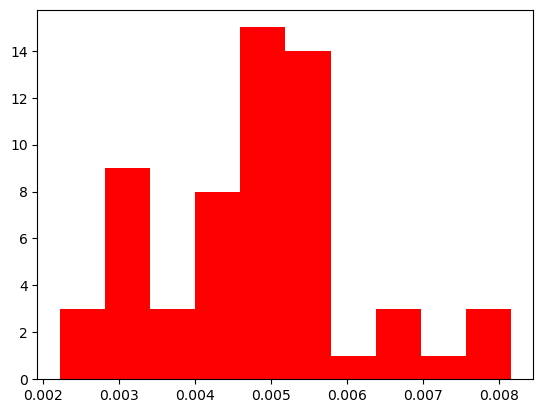

In [61]:
plt.hist(tuners_df["Score"][tuners_df["species"] == "ecoli_MG165_genome_part2"], color = "red")



/hpc/group/ohlab/doingg/miniconda3/envs/tfkg/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


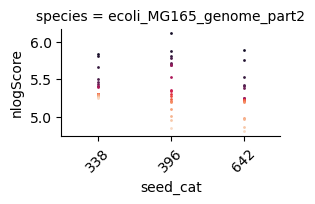

In [62]:
tuners_df['seed_cat'] = tuners_df["seed"].astype('category')
tuners_df['nlogScore'] = np.negative(np.log(tuners_df["Score"]))
g = sns.FacetGrid(tuners_df, col = "species", height=2, aspect=1.5, hue = "rank",palette = "rocket", sharey = False)
g.map(sns.stripplot,"seed_cat","nlogScore", 
      size = 2, 
      #hue = "species"#, 
      #palette = "rocket"
     )
g.set_xticklabels(rotation=45)


(array([ 3.,  4.,  3., 24.,  9.,  4.,  5.,  5.,  2.,  1.]),
 array([4.80969906, 4.93979652, 5.06989399, 5.19999145, 5.33008892,
        5.46018638, 5.59028385, 5.72038131, 5.85047878, 5.98057624,
        6.11067371]),
 <BarContainer object of 10 artists>)

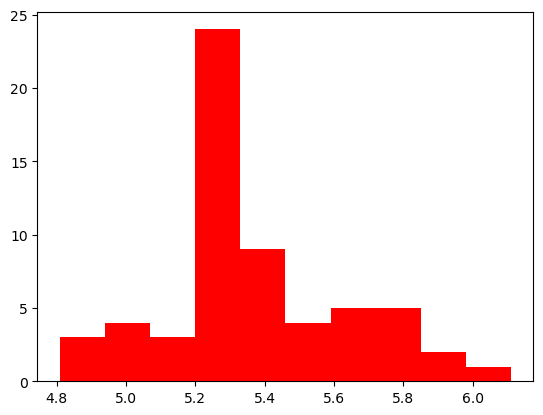

In [63]:
plt.hist(tuners_df["nlogScore"][tuners_df["species"] == "ecoli_MG165_genome_part2"], color = "red")


/hpc/group/ohlab/doingg/miniconda3/envs/tfkg/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


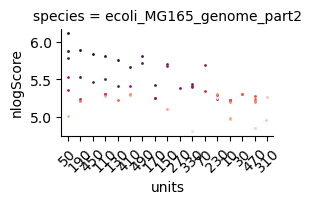

In [64]:

g = sns.FacetGrid(tuners_df, col = "species", height=2, aspect=1.5, hue = "rank",palette = "rocket", sharey = False)
g.map(sns.stripplot,"units","nlogScore", 
      size = 2, 
      #hue = "species"#, 
      #palette = "rocket"
     )
g.set_xticklabels(rotation=45)


/hpc/group/ohlab/doingg/miniconda3/envs/tfkg/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


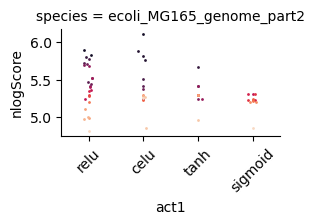

In [65]:

g = sns.FacetGrid(tuners_df, col = "species", height=2, aspect=1.5, hue = "rank",palette = "rocket", sharey = False)
g.map(sns.stripplot,"act1","nlogScore", 
      size = 2, 
      #hue = "species"#, 
      #palette = "rocket"
     )
g.set_xticklabels(rotation=45)

/hpc/group/ohlab/doingg/miniconda3/envs/tfkg/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


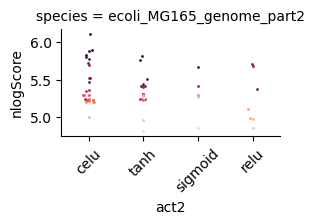

In [66]:

g = sns.FacetGrid(tuners_df, col = "species", height=2, aspect=1.5, hue = "rank",palette = "rocket", sharey = False)
g.map(sns.stripplot,"act2","nlogScore", 
      size = 2, 
      #hue = "species"#, 
      #palette = "rocket"
     )
g.set_xticklabels(rotation=45)

In [67]:
tuners_df

,units,dropout,act1,act2,shuffle,init,kl1,kl2,lr,bs,...,Score,Trial ID,Best step,tuner_key,species,seed,rank,tied_bool,seed_cat,nlogScore
0,450,0.4,relu,celu,True,glorot_normal,6.400000e-09,3.200000e-09,0.381,35,...,0.002932,0082,32,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,0,True,338,5.832019
1,110,0.0,celu,tanh,False,glorot_uniform,1.600000e-09,1.000000e-10,0.811,45,...,0.002982,0050,32,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,1,False,338,5.815292
2,410,0.1,tanh,sigmoid,True,glorot_uniform,2.000000e-10,6.400000e-09,0.461,35,...,0.003466,0051,32,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,2,False,338,5.664872
3,110,0.0,celu,tanh,False,glorot_uniform,1.600000e-09,1.000000e-10,0.811,45,...,0.004083,0049,10,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,3,False,338,5.500916
4,450,0.4,relu,celu,True,glorot_normal,6.400000e-09,3.200000e-09,0.381,35,...,0.004223,0080,16,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,4,True,338,5.467282
5,330,0.4,relu,tanh,True,glorot_normal,3.276800e-06,1.310720e-05,0.501,5,...,0.004328,0072,30,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,5,False,338,5.442634
6,330,0.4,relu,tanh,True,glorot_normal,3.276800e-06,1.310720e-05,0.501,5,...,0.004446,0067,9,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,6,False,338,5.415799
7,410,0.1,tanh,sigmoid,True,glorot_uniform,2.000000e-10,6.400000e-09,0.461,35,...,0.004455,0048,10,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,7,False,338,5.413796
8,330,0.4,relu,tanh,True,glorot_normal,3.276800e-06,1.310720e-05,0.501,5,...,0.004515,0060,5,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,8,False,338,5.400296
9,110,0.4,sigmoid,tanh,False,glorot_normal,1.600000e-09,1.000000e-10,0.501,100,...,0.004962,0046,10,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2,338,9,True,338,5.306042


In [68]:
tuners_df["seed_cat"].sort_values().unique()

['338', '396', '642']
Categories (3, object): ['338', '396', '642']

In [69]:
tuners_long = pd.melt(tuners_df.round(3),
                     id_vars=["Score","tuner/trial_id","Trial ID", "tuner_key","nlogScore","rank", "species","seed"])

tuners_long
                      

,Score,tuner/trial_id,Trial ID,tuner_key,nlogScore,rank,species,seed,variable,value
0,0.003,0080,0082,ecoli_MG165_genome_part2_338,5.832,0,ecoli_MG165_genome_part2,338,units,450
1,0.003,0049,0050,ecoli_MG165_genome_part2_338,5.815,1,ecoli_MG165_genome_part2,338,units,110
2,0.003,0048,0051,ecoli_MG165_genome_part2_338,5.665,2,ecoli_MG165_genome_part2,338,units,410
3,0.004,0036,0049,ecoli_MG165_genome_part2_338,5.501,3,ecoli_MG165_genome_part2,338,units,110
4,0.004,NaN,0080,ecoli_MG165_genome_part2_338,5.467,4,ecoli_MG165_genome_part2,338,units,450
...,...,...,...,...,...,...,...,...,...,...
1135,0.006,NaN,0022,ecoli_MG165_genome_part2_642,5.196,15,ecoli_MG165_genome_part2,642,seed_cat,642
1136,0.007,0038,0048,ecoli_MG165_genome_part2_642,4.982,16,ecoli_MG165_genome_part2,642,seed_cat,642
1137,0.007,0017,0038,ecoli_MG165_genome_part2_642,4.973,17,ecoli_MG165_genome_part2,642,seed_cat,642
1138,0.008,0077,0083,ecoli_MG165_genome_part2_642,4.858,18,ecoli_MG165_genome_part2,642,seed_cat,642


/hpc/group/ohlab/doingg/miniconda3/envs/tfkg/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


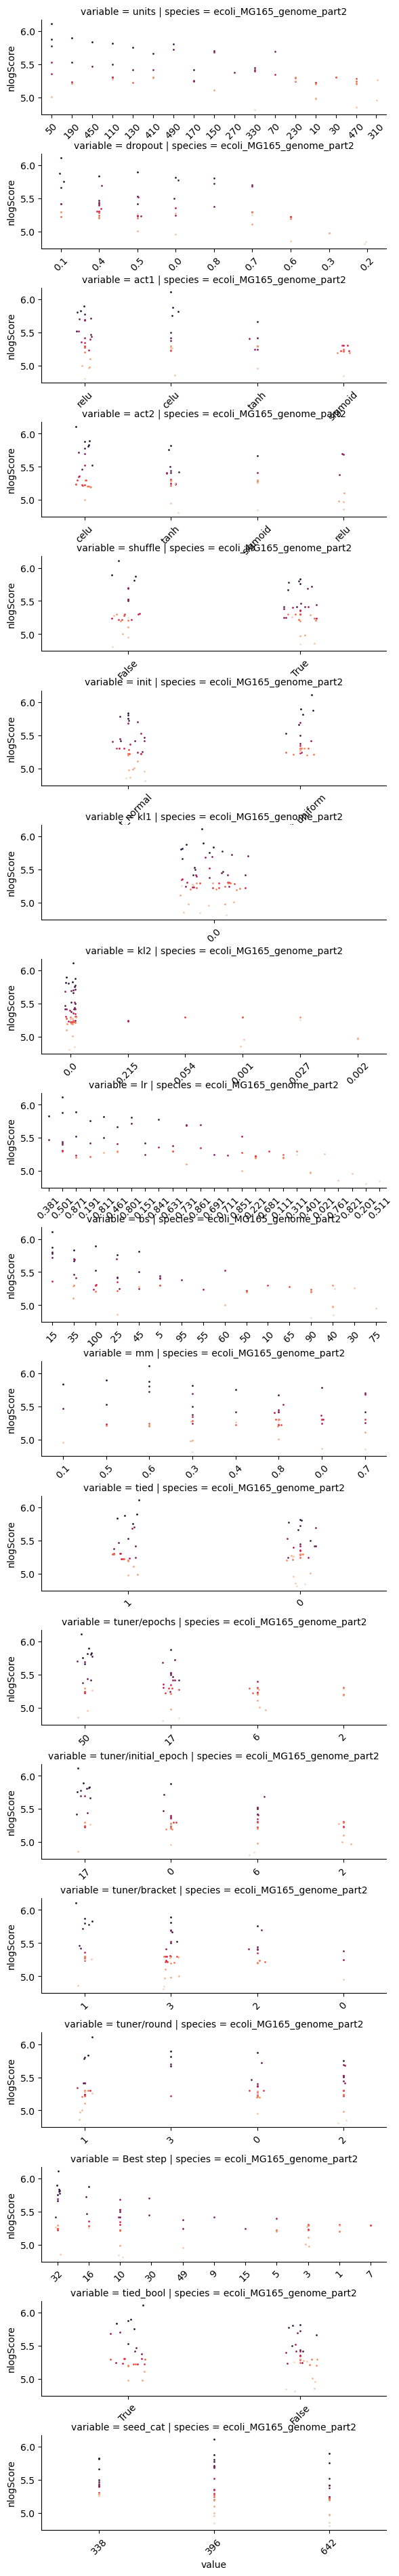

In [70]:
g = sns.FacetGrid(tuners_long, 
                  row = "variable", 
                  col = "species", 
                  height=2, 
                  aspect=3, 
                  hue = "rank",
                  palette = "rocket", 
                  sharex = False,
                  sharey = False)
g.map(sns.stripplot,"value","nlogScore", 
      size = 2, 
      #hue = "species"#, 
      #palette = "rocket"
     )
g.set_xticklabels(rotation=45)

In [71]:
tuners_long["value"].astype(str).sort_values().unique()

array(['0', '0.0', '0.001', '0.002', '0.021', '0.027', '0.054', '0.1',
       '0.111', '0.151', '0.191', '0.2', '0.201', '0.215', '0.221', '0.3',
       '0.311', '0.381', '0.4', '0.401', '0.461', '0.5', '0.501', '0.511',
       '0.6', '0.631', '0.681', '0.691', '0.7', '0.711', '0.731', '0.761',
       '0.8', '0.801', '0.811', '0.821', '0.841', '0.851', '0.861',
       '0.871', '1', '10', '100', '110', '130', '15', '150', '16', '17',
       '170', '190', '2', '230', '25', '270', '3', '30', '310', '32',
       '330', '338', '35', '396', '40', '410', '45', '450', '470', '49',
       '490', '5', '50', '55', '6', '60', '642', '65', '7', '70', '75',
       '9', '90', '95', 'False', 'True', 'celu', 'glorot_normal',
       'glorot_uniform', 'relu', 'sigmoid', 'tanh'], dtype=object)

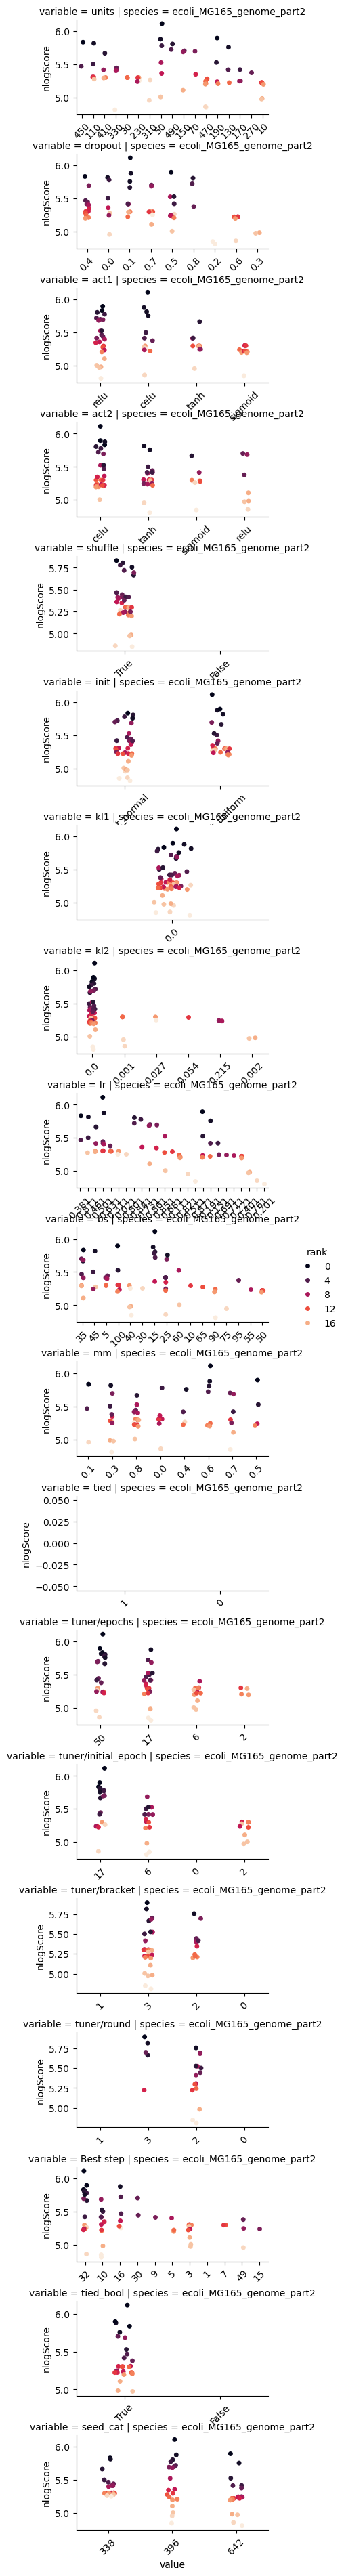

In [72]:
g = sns.catplot(tuners_long,
                x = "value", y = "nlogScore",
                #order = tuners_long["value"].unique(),
                #native_scale=True,
                col = "species",
                row = "variable",
                kind = "strip",
                height = 2, aspect = 2,
                hue = "rank",
                palette = "rocket",
                sharex=False,
                sharey=False
           )
g.set_xticklabels(rotation=45)
g

In [73]:
HP_list = []

for t in tuners.keys():
    sp = t[:-4]
    seed = t[-3:]
    trialsSE = tuners[t].oracle.get_best_trials(num_trials=1)
    i = 0
    for trial in trialsSE:
        HP_list.append(trial.hyperparameters.get_config()["values"] | 
                       {"Score": trial.score}| 
                       {"Trial ID": trial.trial_id} | 
                       {"Best step": trial.best_step} | 
                       {"tuner_key" : t} | 
                       {"species" : sp} | 
                       {"seed" : seed} | 
                       {"rank" : i})
        i+=1

tuners_df = pd.DataFrame(HP_list)

tuners_df["tied_bool"] = tuners_df["tied"].astype("bool")

tuners_df.iloc[:,np.r_[0:12, 20:22]]#.to_csv("name.csv", index=False, na_rep='NaN')

,units,dropout,act1,act2,shuffle,init,kl1,kl2,lr,bs,mm,tied,tuner_key,species
0,450,0.4,relu,celu,True,glorot_normal,6.400000e-09,3.200000e-09,0.381,35,0.1,1,ecoli_MG165_genome_part2_338,ecoli_MG165_genome_part2
1,50,0.1,celu,celu,False,glorot_uniform,1.024000e-07,2.560000e-08,0.501,15,0.6,1,ecoli_MG165_genome_part2_396,ecoli_MG165_genome_part2
2,190,0.5,relu,celu,False,glorot_uniform,6.400000e-09,5.120000e-08,0.871,100,0.5,1,ecoli_MG165_genome_part2_642,ecoli_MG165_genome_part2


In [74]:
tuners_df.iloc[:,np.r_[0:12, 20:22]].select_dtypes(include='number').mean()

units      2.300000e+02
dropout    3.333333e-01
kl1        3.840000e-08
kl2        2.666667e-08
lr         5.843333e-01
bs         5.000000e+01
mm         4.000000e-01
tied       1.000000e+00
dtype: float64